# 1. Data Cleaning and Auditing

The Formula 1 dataset consists of 14 relational CSV tables. Before constructing the
modeling dataset, the raw data is explored and audited to identify missing values,
incorrect data types, duplicate records, and relational-integrity problems.

The cleaning process includes:
- exploratory data analysis before cleaning;
- detection and cleaning of `\N` sentinel values;
- semantic typing of dates and durations;
- primary-key and foreign-key validation;
- investigation and resolution of duplicate `(raceId, driverId)` records;
- and exploratory analysis after cleaning.

The original DataFrames are preserved unchanged. All cleaning operations are
performed on separate copies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

In [ ]:
DATA_PATH = "/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020"

file_names = [
    "circuits",
    "constructors",
    "constructor_results",
    "constructor_standings",
    "drivers",
    "driver_standings",
    "races",
    "results",
    "qualifying",
    "lap_times",
    "pit_stops",
    "sprint_results",
    "seasons",
    "status"
]

raw_data = {}

for name in file_names:
    raw_data[name] = pd.read_csv(
        f"{DATA_PATH}/{name}.csv"
    )

print("Number of tables loaded:", len(raw_data))

## 1.1 Initial Exploratory Data Analysis

The raw tables are first explored without modification. Their dimensions, data types,
summary statistics, missing values, duplicate rows, and placeholder values are
examined programmatically.

This provides a baseline for identifying cleaning requirements and allows the effect
of cleaning to be evaluated later.

In [80]:
for name, df in raw_data.items():
    print(f"\n{name.upper()}")
    display(df.head())


CIRCUITS


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park



CONSTRUCTORS


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso



CONSTRUCTOR_RESULTS


...

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
0,1,1061,830,9,33,2,1,1,1,3,17,25:38.426,1538426,14,1:30.013,1
1,2,1061,1,131,44,1,2,2,2,2,17,+1.430,1539856,17,1:29.937,1
2,3,1061,822,131,77,3,3,3,3,1,17,+7.502,1545928,17,1:29.958,1
3,4,1061,844,6,16,4,4,4,4,0,17,+11.278,1549704,16,1:30.163,1
4,5,1061,846,1,4,6,5,5,5,0,17,+24.111,1562537,16,1:30.566,1



SEASONS


,year,url
0,2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
1,2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2,2007,http://en.wikipedia.org/wiki/2007_Formula_One_...
3,2006,http://en.wikipedia.org/wiki/2006_Formula_One_...
4,2005,http://en.wikipedia.org/wiki/2005_Formula_One_...



STATUS


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


In [81]:
overview = []

for name, df in raw_data.items():
    overview.append({
        "Table": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

overview_df = pd.DataFrame(overview)

display(overview_df)

,Table,Rows,Columns
0,circuits,77,9
1,constructors,212,5
2,constructor_results,12625,5
3,constructor_standings,13391,7
4,drivers,861,9
5,driver_standings,34863,7
6,races,1125,18
7,results,26759,18
8,qualifying,10494,9
9,lap_times,589081,6


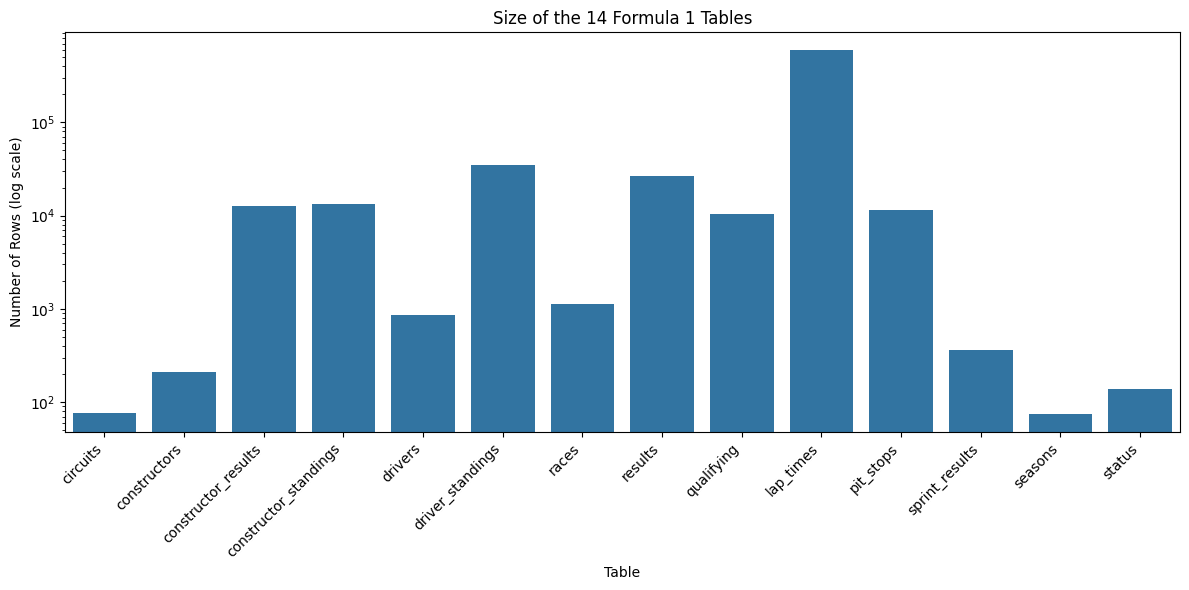

In [82]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=overview_df,
    x="Table",
    y="Rows"
)

plt.yscale("log")
plt.title("Size of the 14 Formula 1 Tables")
plt.xlabel("Table")
plt.ylabel("Number of Rows (log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [83]:
for name, df in raw_data.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    df.info()


CIRCUITS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   77 non-null     int64  
 1   circuitRef  77 non-null     object 
 2   name        77 non-null     object 
 3   location    77 non-null     object 
 4   country     77 non-null     object 
 5   lat         77 non-null     float64
 6   lng         77 non-null     float64
 7   alt         77 non-null     int64  
 8   url         77 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 5.5+ KB

CONSTRUCTORS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   212 non-null    int64 
 1   constructorRef  212 non-null    object
 2   name            212 non-null    object
 3   nationality     212 non-null    

In [84]:
for name, df in raw_data.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    display(df.describe())

,statusId
count,139.000000
mean,71.237410
std,41.092434
min,1.000000
25%,35.500000
50%,72.000000
75%,106.500000
max,141.000000


In [85]:
duplicate_summary = []

for name, df in raw_data.items():
    duplicate_summary.append({
        "Table": name,
        "Exact_Duplicate_Rows": df.duplicated().sum()
    })

duplicate_summary = pd.DataFrame(duplicate_summary)

display(duplicate_summary)

,Table,Exact_Duplicate_Rows
0,circuits,0
1,constructors,0
2,constructor_results,0
3,constructor_standings,0
4,drivers,0
5,driver_standings,0
6,races,0
7,results,0
8,qualifying,0
9,lap_times,0


## 1.2 Sentinel and Missing-Value Analysis

The Formula 1 CSV files use the literal string `\N` as a sentinel representing
missing or unavailable information.

Because `\N` is a text placeholder rather than a proper missing value, its frequency
is measured before cleaning. Both the number and percentage of sentinel values are
calculated for each affected column and visualized before any replacement is made.

In [86]:
sentinel_summary = []

for table_name, df in raw_data.items():
    for column in df.columns:

        count = (
            df[column]
            .astype(str)
            .str.strip()
            .eq(r"\N")
            .sum()
        )

        if count > 0:
            sentinel_summary.append({
                "Table": table_name,
                "Column": column,
                "Count": count,
                "Percentage": count / len(df) * 100
            })

sentinel_summary = pd.DataFrame(sentinel_summary)

sentinel_summary = sentinel_summary.sort_values(
    "Percentage",
    ascending=False
).reset_index(drop=True)

display(sentinel_summary)

,Table,Column,Count,Percentage
0,constructor_results,status,12608,99.865347
1,races,sprint_time,1110,98.666667
2,races,sprint_date,1107,98.400000
3,races,fp3_time,1072,95.288889
4,races,fp2_time,1057,93.955556
5,races,fp1_time,1057,93.955556
6,races,quali_time,1057,93.955556
7,races,fp3_date,1053,93.600000
8,drivers,number,802,93.147503
9,races,fp1_date,1035,92.000000


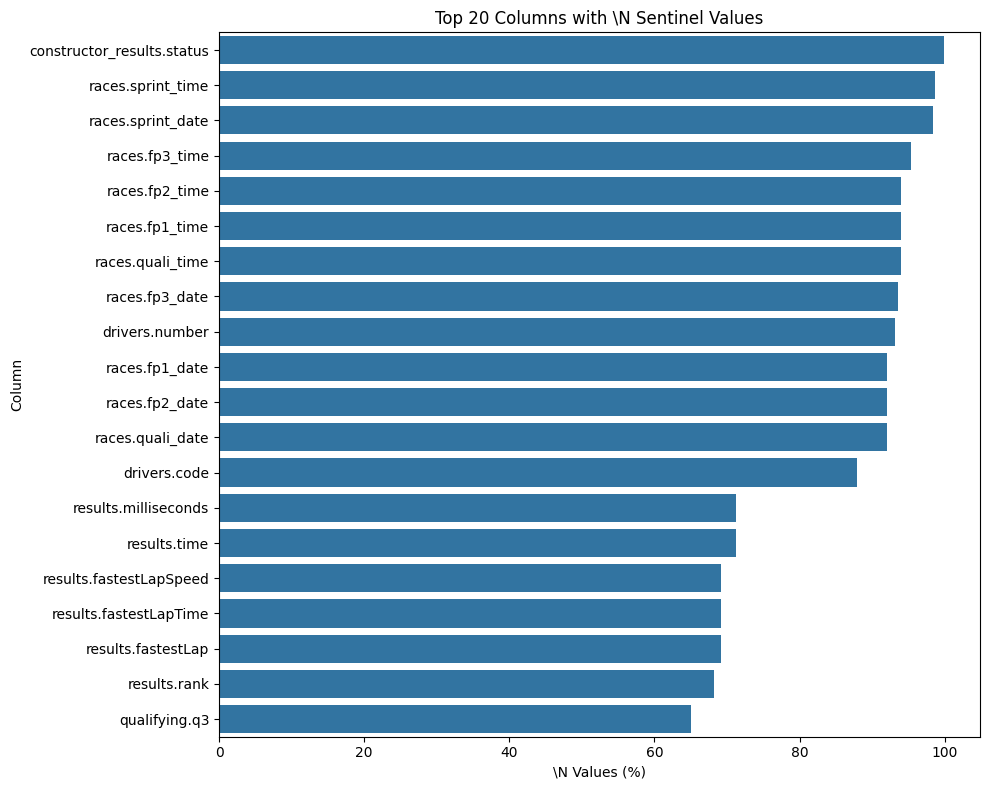

In [87]:
top_sentinels = sentinel_summary.head(20).copy()

top_sentinels["Feature"] = (
    top_sentinels["Table"]
    + "."
    + top_sentinels["Column"]
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_sentinels,
    x="Percentage",
    y="Feature"
)

plt.title("Top 20 Columns with \\N Sentinel Values")
plt.xlabel("\\N Values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

### Total Missingness Before Cleaning

The previous analysis counts only the literal `\N` sentinel values. Some columns also
contain values that Pandas already recognizes as missing (`NaN`).

Therefore, total missingness is calculated using both existing null values and `\N`
sentinels to obtain the complete missing-data picture before cleaning.

In [88]:
missing_before = []

for table_name, df in raw_data.items():
    for column in df.columns:

        null_count = df[column].isnull().sum()

        sentinel_count = (
            df[column]
            .astype(str)
            .str.strip()
            .eq(r"\N")
            .sum()
        )

        total_missing = null_count + sentinel_count

        if total_missing > 0:
            missing_before.append({
                "Table": table_name,
                "Column": column,
                "Missing_Count": total_missing,
                "Missing_Percentage": total_missing / len(df) * 100
            })

missing_before = pd.DataFrame(missing_before)

missing_before = missing_before.sort_values(
    "Missing_Percentage",
    ascending=False
).reset_index(drop=True)

display(missing_before.head(30))

,Table,Column,Missing_Count,Missing_Percentage
0,constructor_results,status,12608,99.865347
1,races,sprint_time,1110,98.666667
2,races,sprint_date,1107,98.400000
3,races,fp3_time,1072,95.288889
4,races,fp2_time,1057,93.955556
5,races,fp1_time,1057,93.955556
6,races,quali_time,1057,93.955556
7,races,fp3_date,1053,93.600000
8,drivers,number,802,93.147503
9,races,fp1_date,1035,92.000000


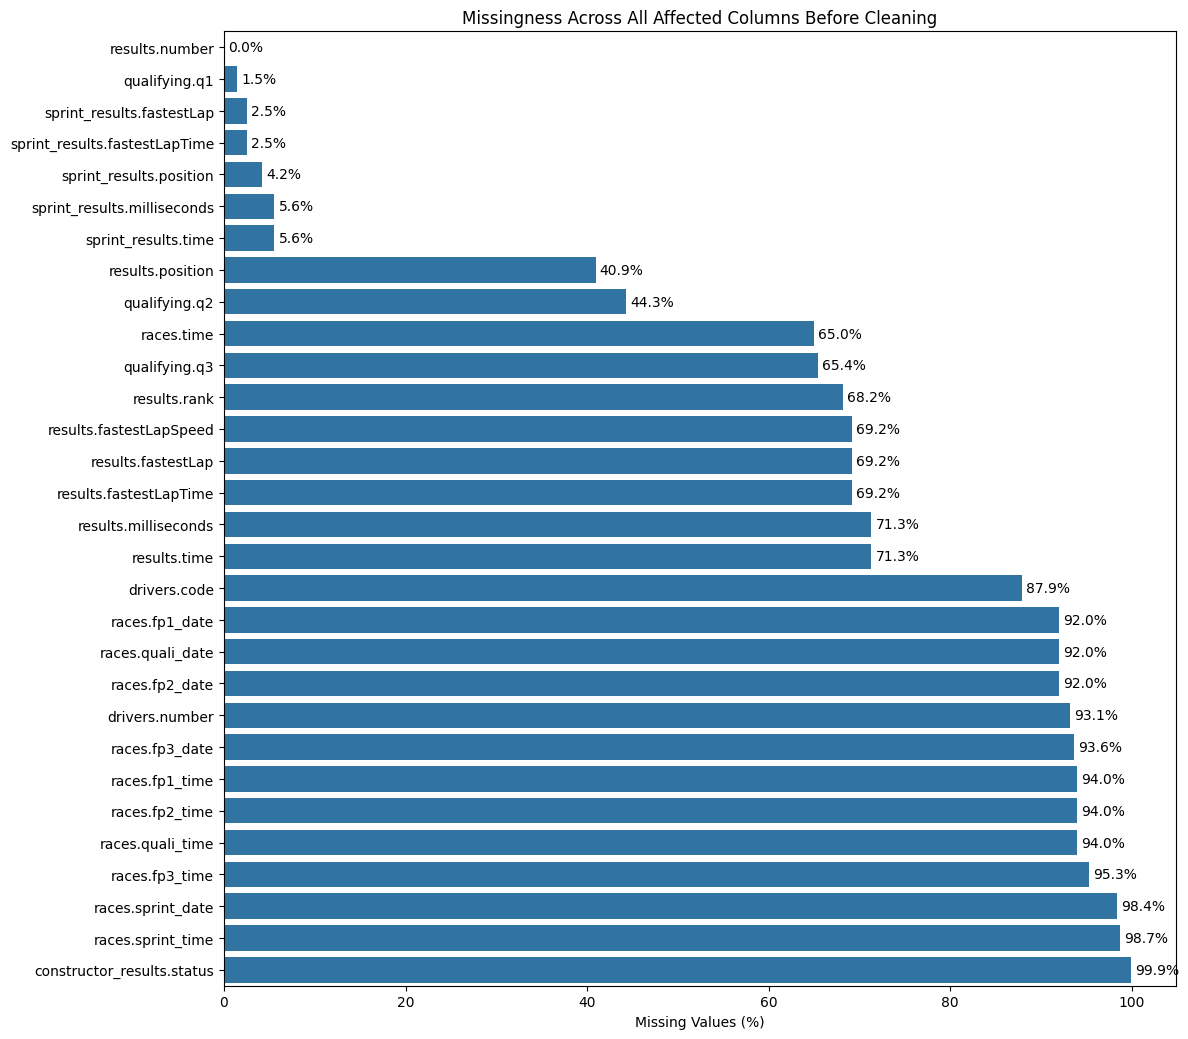

In [130]:
missing_before_plot = (
    missing_before
    .sort_values(
        "Missing_Percentage",
        ascending=True
    )
    .copy()
)

missing_before_plot["Feature"] = (
    missing_before_plot["Table"]
    + "."
    + missing_before_plot["Column"]
)

plt.figure(
    figsize=(
        12,
        max(6, len(missing_before_plot) * 0.35)
    )
)

ax = sns.barplot(
    data=missing_before_plot,
    x="Missing_Percentage",
    y="Feature"
)

plt.title("Missingness Across All Affected Columns Before Cleaning")
plt.xlabel("Missing Values (%)")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

## 1.3 Cleaning Copies

The original tables stored in `raw_data` are preserved without modification.
Independent copies are created in `clean_data`, and all subsequent transformations
are applied only to these copies.

This allows the original source data to remain available for auditing and for direct
before-versus-after comparisons.

In [90]:
clean_data = {
    name: df.copy()
    for name, df in raw_data.items()
}

print("Cleaning copies created:", len(clean_data))

Cleaning copies created: 14


## 1.4 Cleaning Sentinel Values

All `\N` sentinel values are converted to `NaN`, Pandas' standard representation of
missing data.

Since the final objective is to predict whether a driver finishes on the podium, not
every column in the 14 source tables will be used as a predictive feature. Therefore,
missing values are not dropped or imputed at this stage. Instead, they are represented
correctly as `NaN`, and their treatment will be determined later for the features
selected for the final modeling table.

In [91]:
for name in clean_data:
    clean_data[name] = clean_data[name].replace(
        r"^\s*\\N\s*$",
        np.nan,
        regex=True
    )

print("Sentinel replacement complete.")

Sentinel replacement complete.


In [92]:
remaining_sentinels = 0

for name, df in clean_data.items():
    for column in df.columns:

        remaining_sentinels += (
            df[column]
            .astype(str)
            .str.strip()
            .eq(r"\N")
            .sum()
        )

print("Remaining \\N sentinel values:", remaining_sentinels)

Remaining \N sentinel values: 0


## 1.5 Semantic Data Types

Several fields are stored as strings even though they represent dates or durations.

Race-event dates and driver dates of birth are converted to datetime values. Genuine
duration fields, such as qualifying lap times, fastest-lap times, lap times, and pit-stop
durations, are converted to numeric seconds.

The original duration columns are retained while new `_seconds` columns are created,
preserving the original representation for auditing.

`results.time` and `sprint_results.time` are not converted using the generic duration
function because these columns mix full elapsed race times with time gaps such as
`+5.478`, which do not have the same semantic meaning.

In [117]:
race_date_columns = [
    "date",
    "fp1_date",
    "fp2_date",
    "fp3_date",
    "quali_date",
    "sprint_date"
]

for column in race_date_columns:
    clean_data["races"][column] = pd.to_datetime(
        clean_data["races"][column],
        errors="coerce"
    )

clean_data["drivers"]["dob"] = pd.to_datetime(
    clean_data["drivers"]["dob"],
    errors="coerce"
)

print("Date conversion complete.")

Date conversion complete.


In [118]:
numeric_columns = {
    "results": [
        "position",
        "milliseconds",
        "fastestLap",
        "rank",
        "fastestLapSpeed"
    ],
    "sprint_results": [
        "position",
        "milliseconds",
        "fastestLap"
    ]
}

for table_name, columns in numeric_columns.items():
    for column in columns:
        clean_data[table_name][column] = pd.to_numeric(
            clean_data[table_name][column],
            errors="coerce"
        )

print("Numeric semantic typing complete.")

Numeric semantic typing complete.


In [119]:
def time_to_seconds(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "":
        return np.nan

    parts = value.split(":")

    try:
        if len(parts) == 1:
            return float(parts[0])

        elif len(parts) == 2:
            minutes = float(parts[0])
            seconds = float(parts[1])

            return minutes * 60 + seconds

        elif len(parts) == 3:
            hours = float(parts[0])
            minutes = float(parts[1])
            seconds = float(parts[2])

            return (
                hours * 3600
                + minutes * 60
                + seconds
            )

    except ValueError:
        return np.nan

    return np.nan

In [120]:
duration_columns = {
    "results": [
        "fastestLapTime"
    ],

    "qualifying": [
        "q1",
        "q2",
        "q3"
    ],

    "lap_times": [
        "time"
    ],

    "pit_stops": [
        "duration"
    ],

    "sprint_results": [
        "fastestLapTime"
    ]
}

In [121]:
for table_name, columns in duration_columns.items():

    for column in columns:

        clean_data[table_name][
            f"{column}_seconds"
        ] = (
            clean_data[table_name][column]
            .apply(time_to_seconds)
        )

print("Duration conversion complete.")

Duration conversion complete.


In [122]:
print("DATE TYPES")
print("-" * 40)

print(
    clean_data["races"][
        race_date_columns
    ].dtypes
)

print(
    "\ndrivers.dob =",
    clean_data["drivers"]["dob"].dtype
)

DATE TYPES
----------------------------------------
date           datetime64[ns]
fp1_date       datetime64[ns]
fp2_date       datetime64[ns]
fp3_date       datetime64[ns]
quali_date     datetime64[ns]
sprint_date    datetime64[ns]
dtype: object

drivers.dob = datetime64[ns]


In [123]:
print("NUMERIC TYPES")
print("-" * 40)

for table_name, columns in numeric_columns.items():

    print(f"\n{table_name.upper()}")

    for column in columns:
        print(
            f"{column}:",
            clean_data[table_name][column].dtype
        )

NUMERIC TYPES
----------------------------------------

RESULTS
position: float64
milliseconds: float64
fastestLap: float64
rank: float64
fastestLapSpeed: float64

SPRINT_RESULTS
position: float64
milliseconds: float64
fastestLap: float64


In [124]:
print("DURATION TYPES")
print("-" * 40)

duration_check_columns = {
    "results": [
        "fastestLapTime_seconds"
    ],

    "qualifying": [
        "q1_seconds",
        "q2_seconds",
        "q3_seconds"
    ],

    "lap_times": [
        "time_seconds"
    ],

    "pit_stops": [
        "duration_seconds"
    ],

    "sprint_results": [
        "fastestLapTime_seconds"
    ]
}

for table_name, columns in duration_check_columns.items():

    for column in columns:

        print(
            f"{table_name}.{column} =",
            clean_data[table_name][column].dtype
        )

DURATION TYPES
----------------------------------------
results.fastestLapTime_seconds = float64
qualifying.q1_seconds = float64
qualifying.q2_seconds = float64
qualifying.q3_seconds = float64
lap_times.time_seconds = float64
pit_stops.duration_seconds = float64
sprint_results.fastestLapTime_seconds = float64


In [125]:
display(
    clean_data["qualifying"][
        [
            "q1",
            "q1_seconds",
            "q2",
            "q2_seconds",
            "q3",
            "q3_seconds"
        ]
    ].head(10)
)

,q1,q1_seconds,q2,q2_seconds,q3,q3_seconds
0,1:26.572,86.572,1:25.187,85.187,1:26.714,86.714
1,1:26.103,86.103,1:25.315,85.315,1:26.869,86.869
2,1:25.664,85.664,1:25.452,85.452,1:27.079,87.079
3,1:25.994,85.994,1:25.691,85.691,1:27.178,87.178
4,1:25.960,85.960,1:25.518,85.518,1:27.236,87.236
5,1:26.427,86.427,1:26.101,86.101,1:28.527,88.527
6,1:26.295,86.295,1:26.059,86.059,1:28.687,88.687
7,1:26.381,86.381,1:26.063,86.063,1:29.041,89.041
8,1:26.919,86.919,1:26.164,86.164,1:29.593,89.593
9,1:26.702,86.702,1:25.842,85.842,NaN,NaN


The semantic-typing step converted all relevant race-event dates and driver dates of
birth into datetime values.

Numeric result fields that were previously stored as text were converted to numeric
types after sentinel cleaning.

Relevant duration fields were converted to seconds while preserving the original
columns. Mixed-format race-time columns were intentionally excluded from generic
duration conversion because they contain both full elapsed times and time gaps.

The success of these conversions is validated again during the post-cleaning EDA.

## 1.6 Primary-Key Integrity

Each table's primary key is checked for two requirements:

1. Primary-key values must not be missing.
2. Primary-key values must uniquely identify rows.

Composite keys are used for tables such as lap times and pit stops, where multiple
columns together identify one observation.

In [97]:
primary_keys = {
    "circuits": ["circuitId"],
    "constructors": ["constructorId"],
    "constructor_results": ["constructorResultsId"],
    "constructor_standings": ["constructorStandingsId"],
    "drivers": ["driverId"],
    "driver_standings": ["driverStandingsId"],
    "races": ["raceId"],
    "results": ["resultId"],
    "qualifying": ["qualifyId"],
    "lap_times": ["raceId", "driverId", "lap"],
    "pit_stops": ["raceId", "driverId", "stop"],
    "sprint_results": ["resultId"],
    "seasons": ["year"],
    "status": ["statusId"]
}

pk_results = []

for table_name, keys in primary_keys.items():

    df = clean_data[table_name]

    null_count = (
        df[keys]
        .isnull()
        .any(axis=1)
        .sum()
    )

    duplicate_count = (
        df
        .duplicated(subset=keys)
        .sum()
    )

    pk_results.append({
        "Table": table_name,
        "Primary_Key": " + ".join(keys),
        "Null_PK_Rows": null_count,
        "Duplicate_PK_Rows": duplicate_count,
        "Valid": null_count == 0 and duplicate_count == 0
    })

pk_results = pd.DataFrame(pk_results)

display(pk_results)

,Table,Primary_Key,Null_PK_Rows,Duplicate_PK_Rows,Valid
0,circuits,circuitId,0,0,True
1,constructors,constructorId,0,0,True
2,constructor_results,constructorResultsId,0,0,True
3,constructor_standings,constructorStandingsId,0,0,True
4,drivers,driverId,0,0,True
5,driver_standings,driverStandingsId,0,0,True
6,races,raceId,0,0,True
7,results,resultId,0,0,True
8,qualifying,qualifyId,0,0,True
9,lap_times,raceId + driverId + lap,0,0,True


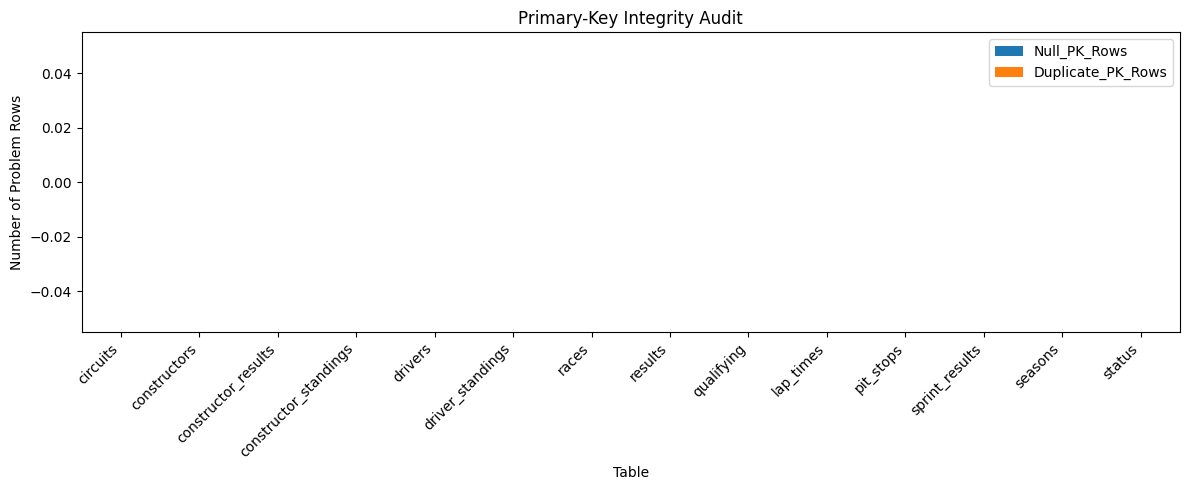

In [98]:
pk_results.set_index("Table")[
    ["Null_PK_Rows", "Duplicate_PK_Rows"]
].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Primary-Key Integrity Audit")
plt.xlabel("Table")
plt.ylabel("Number of Problem Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 1.7 Foreign-Key Integrity

The Formula 1 dataset is relational, so foreign-key values are checked against the
corresponding primary keys in their parent tables.

For example, every `driverId` appearing in `results` should correspond to an existing
driver in `drivers`, and every `raceId` in `qualifying` should correspond to an
existing race in `races`.

An invalid reference indicates a broken relationship between tables.

In [99]:
foreign_keys = [
    ("races", "circuitId", "circuits", "circuitId"),

    ("results", "raceId", "races", "raceId"),
    ("results", "driverId", "drivers", "driverId"),
    ("results", "constructorId", "constructors", "constructorId"),
    ("results", "statusId", "status", "statusId"),

    ("qualifying", "raceId", "races", "raceId"),
    ("qualifying", "driverId", "drivers", "driverId"),
    ("qualifying", "constructorId", "constructors", "constructorId"),

    ("lap_times", "raceId", "races", "raceId"),
    ("lap_times", "driverId", "drivers", "driverId"),

    ("pit_stops", "raceId", "races", "raceId"),
    ("pit_stops", "driverId", "drivers", "driverId"),

    ("driver_standings", "raceId", "races", "raceId"),
    ("driver_standings", "driverId", "drivers", "driverId"),

    ("constructor_results", "raceId", "races", "raceId"),
    ("constructor_results", "constructorId", "constructors", "constructorId"),

    ("constructor_standings", "raceId", "races", "raceId"),
    ("constructor_standings", "constructorId", "constructors", "constructorId"),

    ("sprint_results", "raceId", "races", "raceId"),
    ("sprint_results", "driverId", "drivers", "driverId"),
    ("sprint_results", "constructorId", "constructors", "constructorId"),
    ("sprint_results", "statusId", "status", "statusId")
]

fk_results = []

for child_table, foreign_key, parent_table, primary_key in foreign_keys:

    child_values = clean_data[child_table][foreign_key].dropna()
    parent_values = clean_data[parent_table][primary_key].dropna()

    invalid_count = (
        ~child_values.isin(parent_values)
    ).sum()

    fk_results.append({
        "Child_Table": child_table,
        "Foreign_Key": foreign_key,
        "Parent_Table": parent_table,
        "Parent_Key": primary_key,
        "Invalid_References": invalid_count,
        "Valid": invalid_count == 0
    })

fk_results = pd.DataFrame(fk_results)

display(fk_results)

,Child_Table,Foreign_Key,Parent_Table,Parent_Key,Invalid_References,Valid
0,races,circuitId,circuits,circuitId,0,True
1,results,raceId,races,raceId,0,True
2,results,driverId,drivers,driverId,0,True
3,results,constructorId,constructors,constructorId,0,True
4,results,statusId,status,statusId,0,True
5,qualifying,raceId,races,raceId,0,True
6,qualifying,driverId,drivers,driverId,0,True
7,qualifying,constructorId,constructors,constructorId,0,True
8,lap_times,raceId,races,raceId,0,True
9,lap_times,driverId,drivers,driverId,0,True


In [100]:
fk_problems = fk_results[
    fk_results["Invalid_References"] > 0
]

if fk_problems.empty:
    print("All tested foreign-key relationships reconcile successfully.")
else:
    display(fk_problems)

All tested foreign-key relationships reconcile successfully.


## 1.8 Driver-Race Grain Audit

The required unit of analysis is one driver entering one race. Therefore,
`(raceId, driverId)` must be unique in the modeling table.

Historical Formula 1 data may contain multiple result rows for the same driver in the
same race because early Formula 1 allowed shared drives, where drivers could swap cars
during a race.

These records are genuine historical observations rather than ordinary duplicate
CSV rows. They are therefore identified and investigated separately before applying
a resolution rule.

In [101]:
duplicate_mask = clean_data["results"].duplicated(
    subset=["raceId", "driverId"],
    keep=False
)

duplicate_driver_races = (
    clean_data["results"]
    .loc[duplicate_mask]
    .sort_values(
        ["raceId", "driverId", "positionOrder", "resultId"]
    )
)

duplicate_groups = (
    duplicate_driver_races[
        ["raceId", "driverId"]
    ]
    .drop_duplicates()
)

print(
    "Rows involved in duplicated driver-race groups:",
    len(duplicate_driver_races)
)

print(
    "Number of duplicated (raceId, driverId) combinations:",
    len(duplicate_groups)
)

display(duplicate_driver_races)

Rows involved in duplicated driver-race groups: 176
Number of duplicated (raceId, driverId) combinations: 85


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,time_seconds,fastestLapTime_seconds
13188,13189,540,229,54,10,0,NaN,F,26,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,81,NaN,NaN
13191,13192,540,229,57,23,0,NaN,F,29,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,97,NaN,NaN
17362,17363,717,373,172,1,1,7,7,7,0.0,102,NaN,NaN,NaN,NaN,NaN,NaN,60,NaN,NaN
24298,24304,717,373,172,2,1,NaN,R,12,0.0,54,NaN,NaN,NaN,NaN,NaN,NaN,98,NaN,NaN
17740,17741,733,465,172,48,0,NaN,W,22,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,54,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20142,20143,838,627,154,20,6,NaN,R,12,0.0,10,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN,NaN
20183,20184,839,579,51,60,7,NaN,R,13,0.0,34,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN
20163,20164,839,579,51,18,1,NaN,R,15,1.0,23,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN
20182,20183,839,647,6,48,6,2,2,2,3.0,80,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN


In [102]:
duplicate_years = duplicate_driver_races.merge(
    clean_data["races"][["raceId", "year"]],
    on="raceId",
    how="left"
)

duplicates_by_year = (
    duplicate_years
    .groupby("year")
    .size()
    .reset_index(name="Duplicate_Rows")
)

display(duplicates_by_year)

,year,Duplicate_Rows
0,1950,8
1,1951,8
2,1952,6
3,1953,30
4,1954,33
5,1955,33
6,1956,24
7,1957,16
8,1958,6
9,1960,2


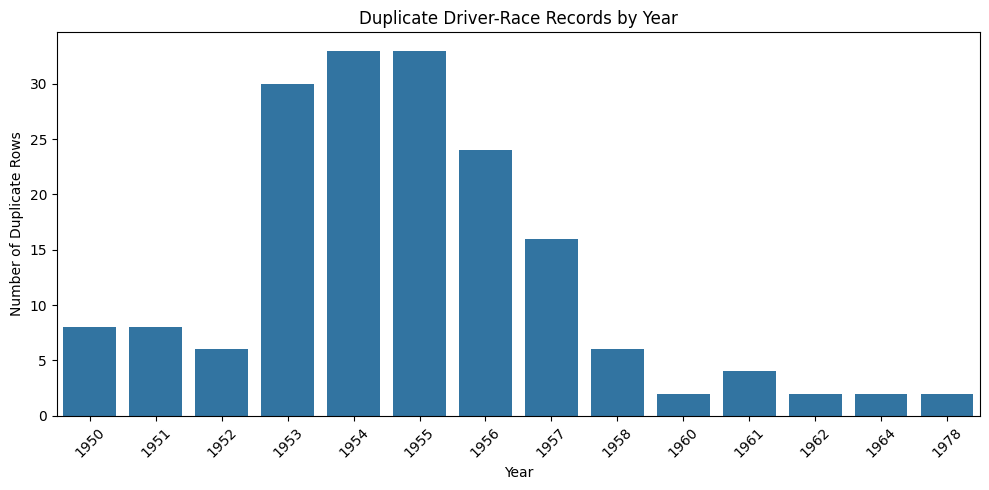

In [103]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=duplicates_by_year,
    x="year",
    y="Duplicate_Rows"
)

plt.title("Duplicate Driver-Race Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Duplicate Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Shared-Drive Resolution

Multiple rows for one `(raceId, driverId)` cannot remain because each final row must
represent exactly one podium outcome for one driver in one race.

For duplicated driver-race groups, the row with the smallest `positionOrder` is
retained. This provides a deterministic driver-level race outcome and ensures that
if any recorded result for the driver represents their best finishing classification,
that result is retained.

If multiple records have the same `positionOrder`, the smallest `resultId` is used
as a deterministic tie-breaker.

`positionOrder` is post-race information and is used here only to resolve the
historical result records and later construct the podium target. It will not be used
as a predictive feature.

After resolution, `(raceId, driverId)` uniqueness is checked again to confirm the
required one-driver-per-race modeling grain. <!--  -->

In [104]:
duplicate_group_sizes = (
    clean_data["results"]
    .groupby(["raceId", "driverId"])
    .size()
    .reset_index(name="Rows_Per_Driver_Race")
)

duplicate_group_sizes = duplicate_group_sizes[
    duplicate_group_sizes["Rows_Per_Driver_Race"] > 1
]

print("Number of duplicated driver-race groups:", len(duplicate_group_sizes))
print(
    "Extra rows that must be removed:",
    (duplicate_group_sizes["Rows_Per_Driver_Race"] - 1).sum()
)

display(
    duplicate_group_sizes["Rows_Per_Driver_Race"]
    .value_counts()
    .sort_index()
    .rename_axis("Rows_Per_Driver_Race")
    .reset_index(name="Number_of_Groups")
)

Number of duplicated driver-race groups: 85
Extra rows that must be removed: 91


,Rows_Per_Driver_Race,Number_of_Groups
0,2,79
1,3,6


In [105]:
results_model = (
    clean_data["results"]
    .sort_values(
        ["raceId", "driverId", "positionOrder", "resultId"],
        ascending=[True, True, True, True]
    )
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    "Rows before duplicate resolution:",
    len(clean_data["results"])
)

print(
    "Rows after duplicate resolution:",
    len(results_model)
)

print(
    "Rows removed:",
    len(clean_data["results"]) - len(results_model)
)

Rows before duplicate resolution: 26759
Rows after duplicate resolution: 26668
Rows removed: 91


In [106]:
remaining_driver_race_duplicates = (
    results_model
    .duplicated(
        subset=["raceId", "driverId"]
    )
    .sum()
)

print(
    "Remaining duplicate (raceId, driverId) pairs:",
    remaining_driver_race_duplicates
)

assert remaining_driver_race_duplicates == 0

print("Required one-row-per-driver-per-race grain confirmed.")

Remaining duplicate (raceId, driverId) pairs: 0
Required one-row-per-driver-per-race grain confirmed.


## 1.9 Post-Cleaning Exploratory Data Analysis

After cleaning, the data is explored again to evaluate the impact of the transformations.

The post-cleaning EDA visually examines:
- missingness after converting sentinel values to proper `NaN`;
- patterns in missing data;
- the distributions of newly converted duration variables;
- the success of semantic-type conversions;
- the effect of resolving duplicate driver-race records;
- and the final data-quality audit.

These visualizations are used to verify that cleaning produced the intended changes
without introducing unexpected data-quality problems.

In [134]:
missing_after = []

for table_name, df in clean_data.items():

    for column in df.columns:

        # Derived columns are excluded so the same missingness
        # is not counted twice.
        if column.endswith("_seconds"):
            continue

        missing_count = df[column].isnull().sum()

        if missing_count > 0:
            missing_after.append({
                "Feature": f"{table_name}.{column}",
                "Missing_Count": missing_count,
                "Missing_Percentage": (
                    missing_count / len(df) * 100
                )
            })

missing_after = pd.DataFrame(missing_after)

missing_after_plot = (
    missing_after
    .sort_values(
        "Missing_Percentage",
        ascending=True
    )
    .copy()
)

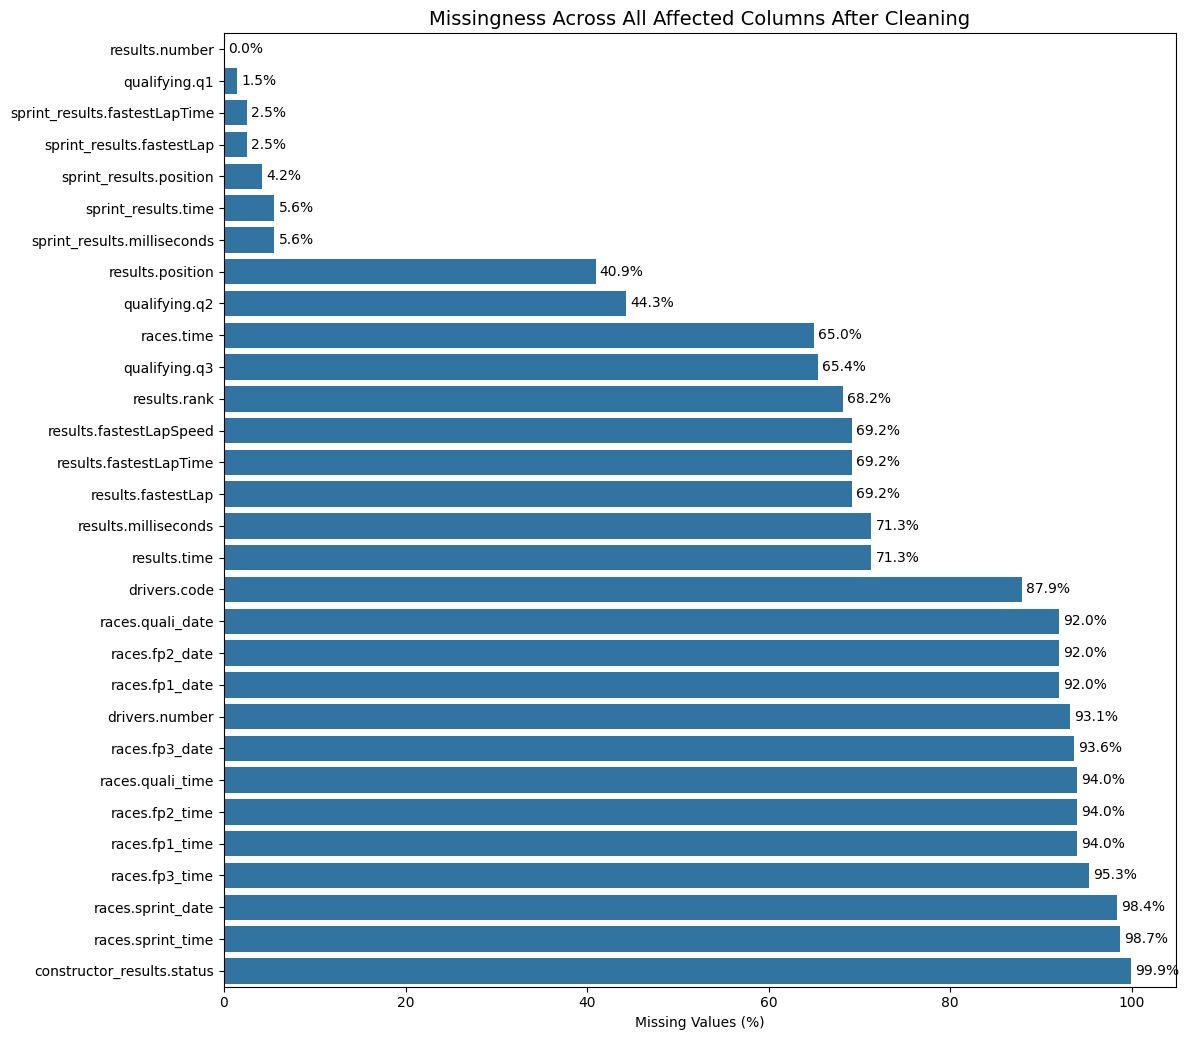

In [135]:
plt.figure(
    figsize=(
        12,
        max(7, len(missing_after_plot) * 0.35)
    )
)

ax = sns.barplot(
    data=missing_after_plot,
    x="Missing_Percentage",
    y="Feature"
)

plt.title(
    "Missingness Across All Affected Columns After Cleaning",
    fontsize=14
)

plt.xlabel("Missing Values (%)")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Missingness Patterns

Missing-value percentages show how much data is unavailable, while a missingness
matrix shows how those missing values are distributed across observations.

This is useful because some missingness in the Formula 1 dataset is structural rather
than random. For example, later qualifying sessions are not available for every driver.

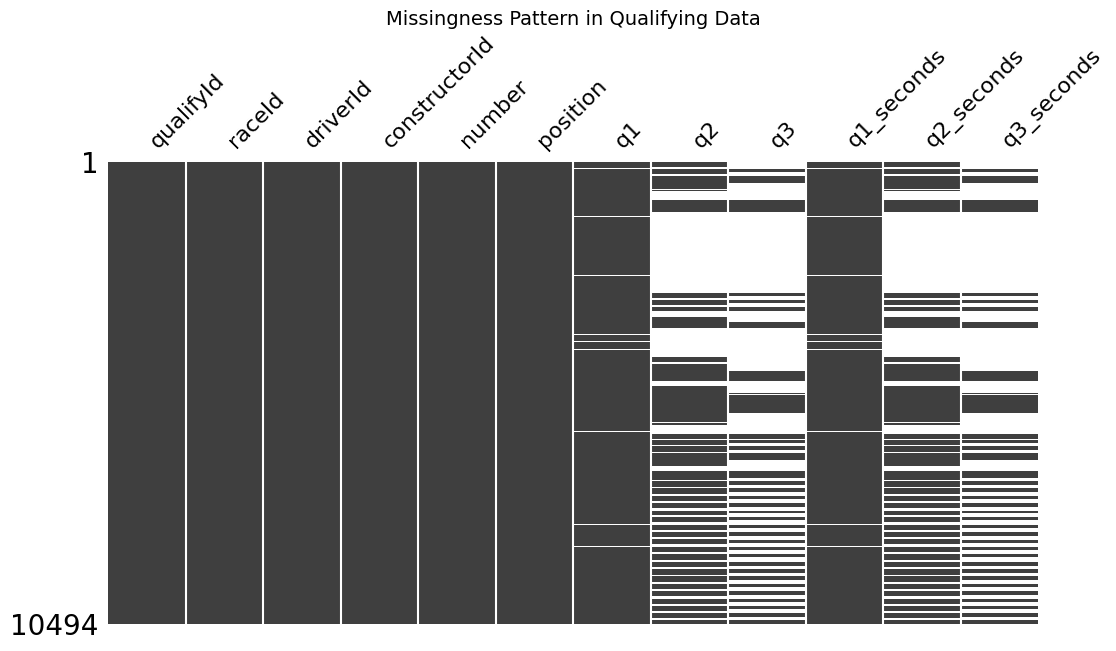

In [136]:
msno.matrix(
    clean_data["qualifying"],
    figsize=(12, 6),
    sparkline=False
)

plt.title(
    "Missingness Pattern in Qualifying Data",
    fontsize=14
)

plt.show()

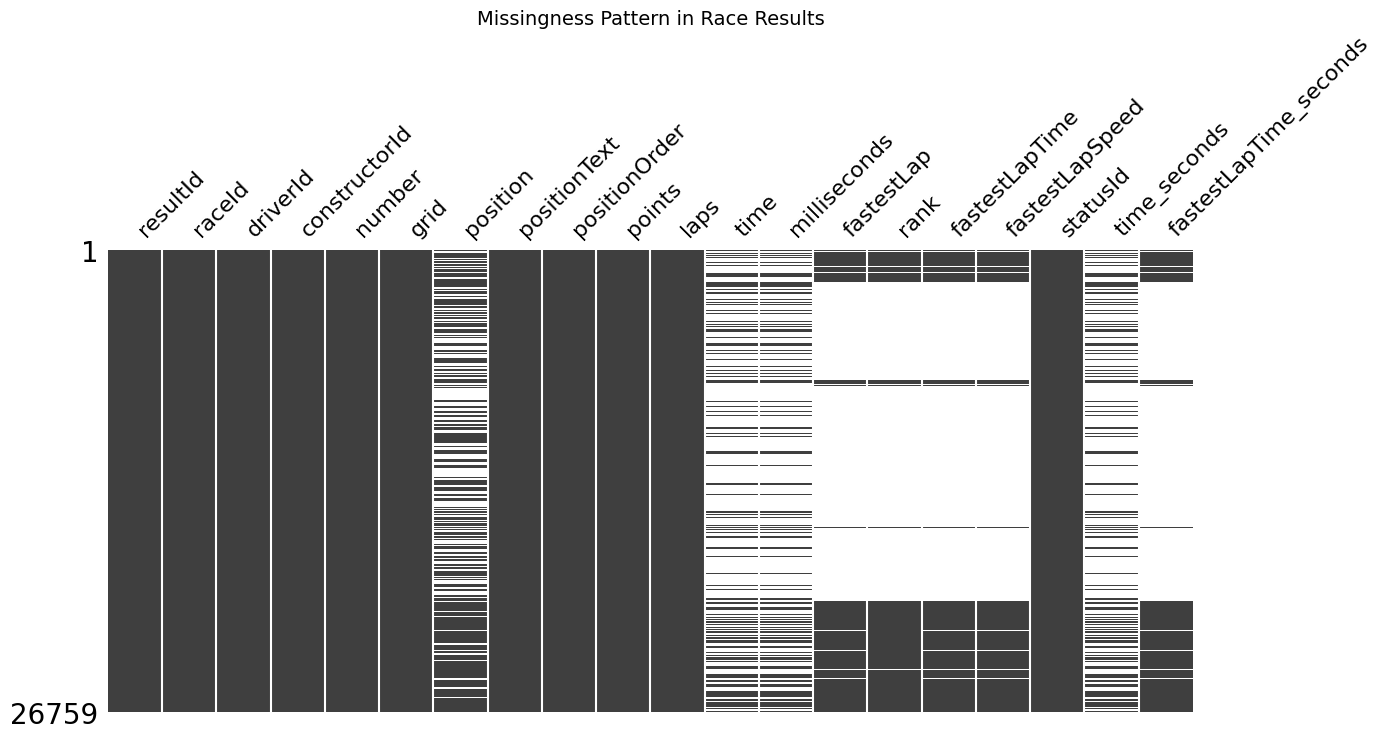

In [137]:
msno.matrix(
    clean_data["results"],
    figsize=(14, 6),
    sparkline=False
)

plt.title(
    "Missingness Pattern in Race Results",
    fontsize=14
)

plt.show()

### Distribution of Converted Duration Variables

The duration fields were converted from formatted strings into numeric seconds.
Their distributions are examined after conversion to verify that the resulting values
behave like meaningful continuous numerical variables and to identify possible extreme
values or unusual patterns.

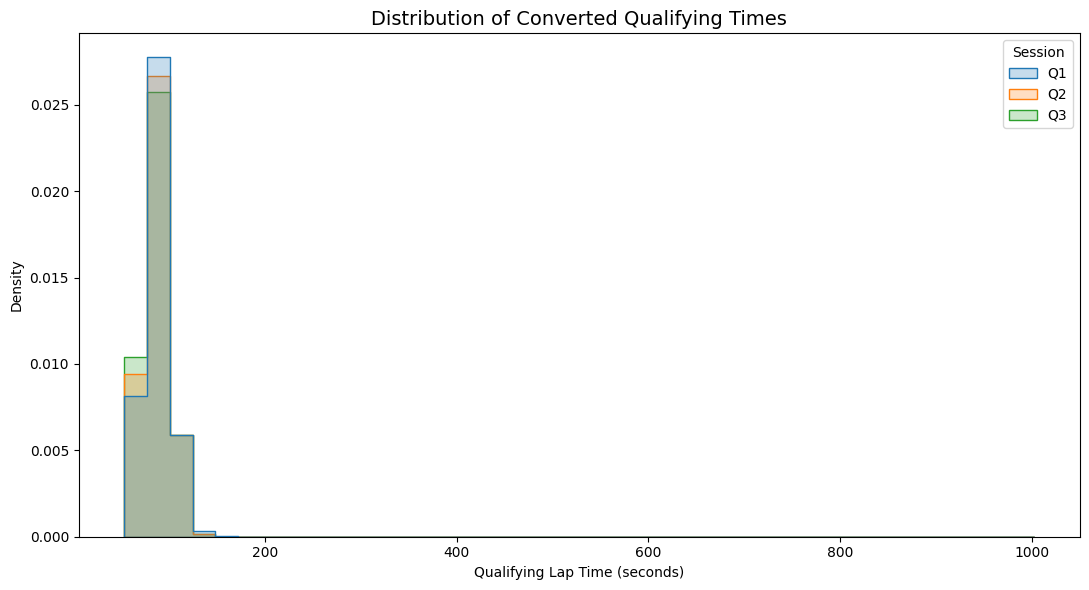

In [138]:
qualifying_seconds = (
    clean_data["qualifying"][
        [
            "q1_seconds",
            "q2_seconds",
            "q3_seconds"
        ]
    ]
    .melt(
        var_name="Session",
        value_name="Time_Seconds"
    )
    .dropna()
)

qualifying_seconds["Session"] = (
    qualifying_seconds["Session"]
    .str.replace(
        "_seconds",
        "",
        regex=False
    )
    .str.upper()
)

plt.figure(figsize=(11, 6))

sns.histplot(
    data=qualifying_seconds,
    x="Time_Seconds",
    hue="Session",
    bins=40,
    element="step",
    stat="density",
    common_norm=False
)

plt.title(
    "Distribution of Converted Qualifying Times",
    fontsize=14
)

plt.xlabel("Qualifying Lap Time (seconds)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

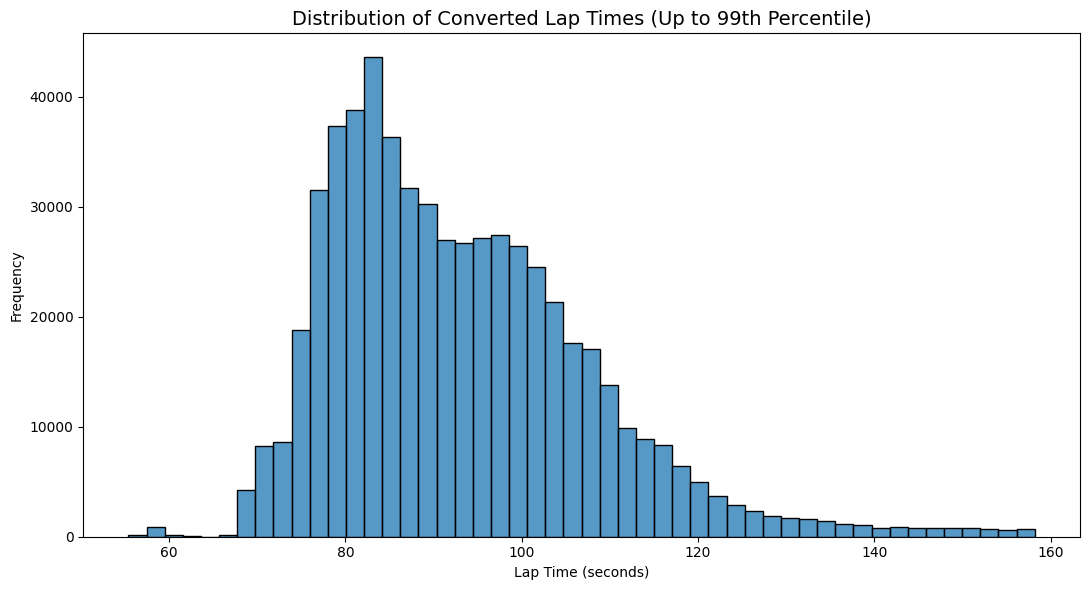

In [140]:
lap_time_limit = (
    clean_data["lap_times"]["time_seconds"]
    .quantile(0.99)
)

plt.figure(figsize=(11, 6))

sns.histplot(
    data=clean_data["lap_times"][
        clean_data["lap_times"]["time_seconds"]
        <= lap_time_limit
    ],
    x="time_seconds",
    bins=50
)

plt.title(
    "Distribution of Converted Lap Times (Up to 99th Percentile)",
    fontsize=14
)

plt.xlabel("Lap Time (seconds)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

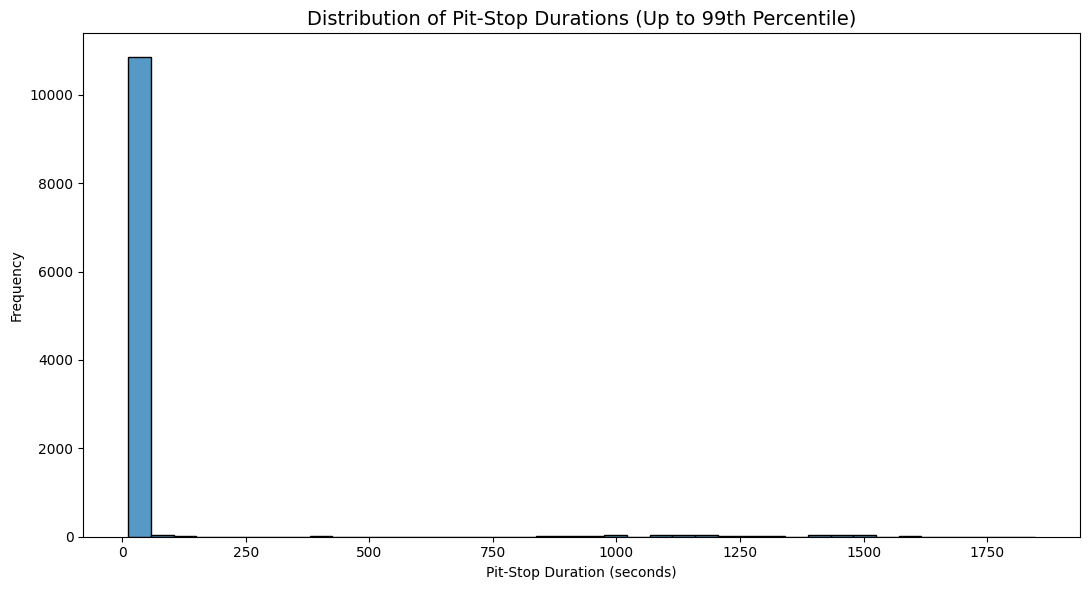

In [141]:
pit_stop_limit = (
    clean_data["pit_stops"]["duration_seconds"]
    .quantile(0.99)
)

plt.figure(figsize=(11, 6))

sns.histplot(
    data=clean_data["pit_stops"][
        clean_data["pit_stops"]["duration_seconds"]
        <= pit_stop_limit
    ],
    x="duration_seconds",
    bins=40
)

plt.title(
    "Distribution of Pit-Stop Durations (Up to 99th Percentile)",
    fontsize=14
)

plt.xlabel("Pit-Stop Duration (seconds)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [109]:
print("FINAL DATA CLEANING CHECKS")
print("=" * 45)

print(
    "Remaining \\N sentinels:",
    sum(
        (df.astype(str) == r"\N").sum().sum()
        for df in clean_data.values()
    )
)

print(
    "Invalid primary-key checks:",
    (~pk_results["Valid"]).sum()
)

print(
    "Invalid foreign-key checks:",
    (~fk_results["Valid"]).sum()
)

print(
    "Duplicate (raceId, driverId) rows:",
    results_model.duplicated(
        ["raceId", "driverId"]
    ).sum()
)

FINAL DATA CLEANING CHECKS
Remaining \N sentinels: 0
Invalid primary-key checks: 0
Invalid foreign-key checks: 0
Duplicate (raceId, driverId) rows: 0


### Semantic-Type Validation After Cleaning

The semantic conversions are validated after cleaning to confirm that date fields are
stored as datetime values and duration fields are numeric.

The validation also checks whether any originally available values became missing during
conversion. This helps identify parsing failures rather than assuming that successful code
execution means every value was converted correctly.

In [115]:
date_validation = []

for column in race_date_columns:

    raw_available = (
        raw_data["races"][column].notna()
        &
        raw_data["races"][column]
        .astype(str)
        .str.strip()
        .ne(r"\N")
    )

    cleaned_available = (
        clean_data["races"][column].notna()
    )

    unexpected_failures = (
        raw_available
        &
        ~cleaned_available
    ).sum()

    date_validation.append({
        "Table": "races",
        "Column": column,
        "Raw_Non_Missing": raw_available.sum(),
        "Parsed_Non_Missing": cleaned_available.sum(),
        "Unexpected_Parse_Failures": unexpected_failures,
        "Clean_Dtype": str(
            clean_data["races"][column].dtype
        )
    })


raw_dob_available = (
    raw_data["drivers"]["dob"].notna()
    &
    raw_data["drivers"]["dob"]
    .astype(str)
    .str.strip()
    .ne(r"\N")
)

clean_dob_available = (
    clean_data["drivers"]["dob"].notna()
)

date_validation.append({
    "Table": "drivers",
    "Column": "dob",
    "Raw_Non_Missing": raw_dob_available.sum(),
    "Parsed_Non_Missing": clean_dob_available.sum(),
    "Unexpected_Parse_Failures": (
        raw_dob_available
        &
        ~clean_dob_available
    ).sum(),
    "Clean_Dtype": str(
        clean_data["drivers"]["dob"].dtype
    )
})

date_validation_df = pd.DataFrame(
    date_validation
)

display(date_validation_df)

,Table,Column,Raw_Non_Missing,Parsed_Non_Missing,Unexpected_Parse_Failures,Clean_Dtype
0,races,date,1125,1125,0,datetime64[ns]
1,races,fp1_date,90,90,0,datetime64[ns]
2,races,fp2_date,90,90,0,datetime64[ns]
3,races,fp3_date,72,72,0,datetime64[ns]
4,races,quali_date,90,90,0,datetime64[ns]
5,races,sprint_date,18,18,0,datetime64[ns]
6,drivers,dob,861,861,0,datetime64[ns]


In [116]:
duration_validation = []

duration_pairs = {
    "results": {
        "fastestLapTime": "fastestLapTime_seconds"
    },

    "qualifying": {
        "q1": "q1_seconds",
        "q2": "q2_seconds",
        "q3": "q3_seconds"
    },

    "lap_times": {
        "time": "time_seconds"
    },

    "pit_stops": {
        "duration": "duration_seconds"
    },

    "sprint_results": {
        "fastestLapTime": "fastestLapTime_seconds"
    }
}

for table_name, columns in duration_pairs.items():

    for original_column, seconds_column in columns.items():

        raw_available = (
            raw_data[table_name][original_column].notna()
            &
            raw_data[table_name][original_column]
            .astype(str)
            .str.strip()
            .ne(r"\N")
        )

        converted_available = (
            clean_data[table_name][seconds_column].notna()
        )

        unexpected_failures = (
            raw_available
            &
            ~converted_available
        ).sum()

        duration_validation.append({
            "Table": table_name,
            "Original_Column": original_column,
            "Converted_Column": seconds_column,
            "Raw_Non_Missing": raw_available.sum(),
            "Converted_Non_Missing": converted_available.sum(),
            "Unexpected_Parse_Failures": unexpected_failures,
            "Converted_Dtype": str(
                clean_data[table_name][seconds_column].dtype
            )
        })

duration_validation_df = pd.DataFrame(
    duration_validation
)

display(duration_validation_df)

,Table,Original_Column,Converted_Column,Raw_Non_Missing,Converted_Non_Missing,Unexpected_Parse_Failures,Converted_Dtype
0,results,fastestLapTime,fastestLapTime_seconds,8252,8252,0,float64
1,qualifying,q1,q1_seconds,10338,10338,0,float64
2,qualifying,q2,q2_seconds,5847,5847,0,float64
3,qualifying,q3,q3_seconds,3629,3629,0,float64
4,lap_times,time,time_seconds,589081,589081,0,float64
5,pit_stops,duration,duration_seconds,11371,11371,0,float64
6,sprint_results,fastestLapTime,fastestLapTime_seconds,351,351,0,float64


## 1.9 Post-Cleaning Exploratory Data Analysis

After cleaning, the data is explored again to evaluate the impact of the transformations.

The post-cleaning EDA visually examines:
- missingness after converting sentinel values to proper `NaN`;
- patterns in missing data;
- the distributions of newly converted duration variables;
- the success of semantic-type conversions;
- the effect of resolving duplicate driver-race records;
- and the final data-quality audit.

These visualizations are used to verify that cleaning produced the intended changes
without introducing unexpected data-quality problems.

In [132]:
missing_after_plot = (
    missing_after
    .sort_values(
        "Missing_Percentage",
        ascending=True
    )
    .copy()
)

missing_after_plot["Feature"] = (
    missing_after_plot["Table"]
    + "."
    + missing_after_plot["Column"]
)

plt.figure(
    figsize=(
        12,
        max(6, len(missing_after_plot) * 0.35)
    )
)

ax = sns.barplot(
    data=missing_after_plot,
    x="Missing_Percentage",
    y="Feature"
)

plt.title("Missingness Across All Affected Columns After Cleaning")
plt.xlabel("Missing Values (%)")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

KeyError: 'Table'